# DOC-ANNs — Global DOC Map Example

This notebook demonstrates how to use the pre-trained **DOC-ANNa** and **DOC-ANNb** models
to generate a **global map of surface Dissolved Organic Carbon (DOC)** from satellite remote sensing data.

The workflow mirrors the one used in Bonelli et al. (2022) to produce annual and seasonal DOC maps
at 25 km resolution using GlobColour 8-day composites.

> Bonelli et al. (2022), *Remote Sensing of Environment*, 281, 113227.
> https://doi.org/10.1016/j.rse.2022.113227

---

## Workflow overview

```
Satellite NetCDF files                 Model output
─────────────────────                  ────────────
  SST    (GlobColour)  ──┐
  CDOM   (GlobColour)  ──┤  DOC-ANNs   ──►  DOC map (NetCDF + PNG)
  MLD    (CMEMS)       ──┤  (this nb)
  Chl-a  (GlobColour)  ──┘  (optional: OWC switch)
```

---

## Requirements

- Pre-trained model files: `models/DOCANNa.h5` and `models/DOCANNb.h5`
  *(contact abonelli@asu.edu or see README for instructions on how to obtain them)*
- Satellite data files in NetCDF format (see Section 1 for download instructions)
- Python packages: `tensorflow`, `netCDF4`, `scikit-learn`, `numpy`, `matplotlib`, `cartopy`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import os, glob, warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from netCDF4 import Dataset

# Optional: cartopy for map projection (install separately if needed)
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
    print("cartopy available — will use Robinson projection")
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not found — will use simple lat/lon axes")
    print("Install with:  pip install cartopy")

print(f"TensorFlow version: {tf.__version__}")

cartopy not found — will use simple lat/lon axes
Install with:  pip install cartopy
TensorFlow version: 2.16.2


In [2]:
# ============================================================
# CONFIGURATION — edit these paths to match your data
# ============================================================

# Pre-trained model files
PATH_ANNa = "../models/DOCANNa.h5"
PATH_ANNb = "../models/DOCANNb.h5"

# GlobColour NetCDF files — one file per 8-day composite
# Replace the glob patterns with the actual paths on your system
# Data available at: https://hermes.acri.fr/  (GlobColour portal)
# or via the Copernicus Marine Service: https://marine.copernicus.eu/

# ---- DOC-ANNa inputs (coastal / optically complex waters) ----
GLOB_CHL   = "/path/to/GlobColour/CHL1/L3m_*CHL1*"    # Chl-a (OC4)
GLOB_SST   = "/path/to/GlobColour/SST0/L3m_*SST*"     # SST
GLOB_CDOM  = "/path/to/GlobColour/CDOM/L3m_*CDOM443*" # aCDOM(443) — Belanger algo
GLOB_MLD   = "/path/to/GlobColour/MLD0/L3m_*MLD*"     # Mixed layer depth

# ---- Date range to process ----
# Files are sorted chronologically; time lags are handled by index offsets
# (see Section 3 for details on the lag convention)

# Output path for NetCDF and PNG files
OUTPUT_DIR = "../figures/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration set.")
print("Note: run Section 2 to test with synthetic data before connecting real satellite files.")

Configuration set.
Note: run Section 2 to test with synthetic data before connecting real satellite files.


## Section 1 — Download satellite data (GlobColour)

Satellite data products used as model inputs are freely available from:

| Product | Variable | Resolution | Portal |
|---------|----------|------------|--------|
| GlobColour L3m 8-day | SST, Chl-a, aCDOM(443), MLD | 25 km | https://hermes.acri.fr |
| Copernicus Marine Service | SST, MLD | 25 km | https://marine.copernicus.eu |

Each product is distributed as a NetCDF file with dimensions `[lat, lon]`.
The model expects files sorted by date, with the following **time lag convention**:

| Input variable | Time lag | Indexing convention |
|---------------|----------|---------------------|
| Chl-a (ANNa only) | −1 week | Same 8-day period as DOC |
| SST | −1 week | Same 8-day period |
| MLD | −1 week | Same 8-day period |
| aCDOM(443) | −2 weeks | One 8-day composite earlier |

Once downloaded, update the `GLOB_*` paths in the configuration cell above.

---

## Section 2 — Synthetic demo (no satellite data required)

The cells below create a realistic synthetic global dataset so you can run the full
pipeline end-to-end without downloading satellite files.
Real satellite data produce the same output structure but with spatially coherent fields.

In [12]:
# ---- Generate synthetic global fields ----
# Grid: 25 km resolution (~0.25 deg) covering the global ocean

print("Generating synthetic global satellite fields...")

lat = np.arange(-89.875, 90.0, 0.25)
lon = np.arange(-179.875, 180.0, 0.25)
nlat, nlon = len(lat), len(lon)
mlon, mlat = np.meshgrid(lon, lat)

np.random.seed(42)

# Realistic synthetic SST: warm tropics, cold poles, some noise
sst_base = 28 - 0.6 * np.abs(mlat) + 2 * np.cos(np.radians(mlon))
sst = sst_base + np.random.normal(0, 1.5, (nlat, nlon))

# aCDOM(443): higher at high latitudes and coastal edges
cdom = 0.008 + 0.012 * (np.abs(mlat) / 90) + np.random.exponential(0.003, (nlat, nlon))
cdom = np.clip(cdom, 0.002, 0.06)

# MLD: deep in subpolar gyres, shallow in tropics
mld = 20 + 60 * np.abs(np.sin(np.radians(mlat))) + np.random.normal(0, 10, (nlat, nlon))
mld = np.clip(mld, 5, 250)

# Chl-a: bloom at mid-latitudes, very low in subtropical gyres
chl = 0.05 + 0.4 * np.exp(-((np.abs(mlat) - 50) / 20)**2) + np.random.exponential(0.02, (nlat, nlon))
chl = np.clip(chl, 0.003, 2.0)

# Land mask: simple flag (NaN over continents)
# Using a rough approximation — real runs use the satellite land mask
land = np.zeros((nlat, nlon), dtype=bool)
land[(mlat > 10) & (mlat < 75) & (mlon > -15) & (mlon < 60)] = True    # Africa/Europe
land[(mlat > 5)  & (mlat < 80) & (mlon > 60)  & (mlon < 150)] = True   # Asia
land[(mlat > 15) & (mlat < 75) & (mlon > -170) & (mlon < -55)] = True  # N. America
land[(mlat > -55) & (mlat < 15) & (mlon > -80) & (mlon < -35)] = True  # S. America

sst[land] = np.nan
cdom[land] = np.nan
mld[land] = np.nan
chl[land] = np.nan

print(f"Global grid: {nlat} x {nlon} pixels ({nlat*nlon/1e6:.1f}M total)")
print(f"Ocean pixels (approx): {(~land).sum():,}")

Generating synthetic global satellite fields...
Global grid: 720 x 1440 pixels (1.0M total)
Ocean pixels (approx): 690,000


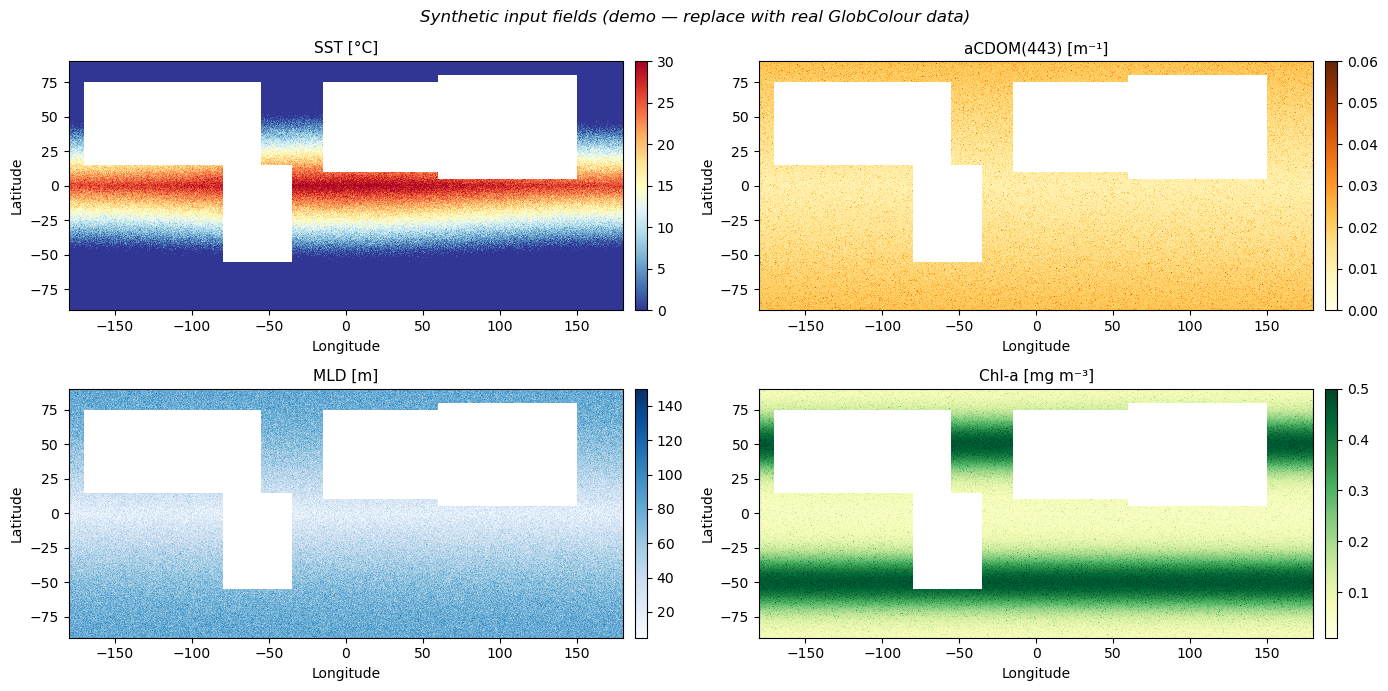

In [13]:
# ---- Visualize the synthetic input fields ----

fig, axes = plt.subplots(2, 2, figsize=(14, 7), subplot_kw={"aspect": "auto"})
fields = [
    (sst,  "SST [°C]",          plt.cm.RdYlBu_r, (0, 30)),
    (cdom, "aCDOM(443) [m⁻¹]",  plt.cm.YlOrBr,   (0, 0.06)),
    (mld,  "MLD [m]",           plt.cm.Blues,    (5, 150)),
    (chl,  "Chl-a [mg m⁻³]",   plt.cm.YlGn,     (0.01, 0.5)),
]

for ax, (field, label, cmap, vlim) in zip(axes.flat, fields):
    im = ax.pcolormesh(lon, lat, field, cmap=cmap, vmin=vlim[0], vmax=vlim[1],
                       shading="auto", rasterized=True)
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.suptitle("Synthetic input fields (demo — replace with real GlobColour data)",
             fontsize=12, style="italic")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}input_fields_demo.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3 — Load pre-trained models

The two ANN models are loaded from `.h5` files.
If the model files are not yet available, a simple stand-in function is used for demonstration.

In [14]:
def load_or_stub(path, name):
    """Load .h5 model, or create a stub function for demonstration."""
    if os.path.exists(path):
        model = tf.keras.models.load_model(path)
        print(f"  Loaded {name} from {path}")
        return model, False
    else:
        print(f"  {name} not found at {path}. Using stub (linear regression on first predictor).")
        return None, True

print("Loading models...")
model_ANNa, stub_ANNa = load_or_stub(PATH_ANNa, "DOC-ANNa")
model_ANNb, stub_ANNb = load_or_stub(PATH_ANNb, "DOC-ANNb")

def stub_predict_ANNa(X):
    """Stub: rough linear approximation for demo purposes only."""
    return 45.0 + 5 * X[:, 0] - 2 * X[:, 1] + 0.02 * X[:, 2] + 1.5 * X[:, 3]

def stub_predict_ANNb(X):
    """Stub: rough linear approximation for demo purposes only."""
    return 52.0 + 3 * X[:, 0] - 1.5 * X[:, 1] + 0.01 * X[:, 2]

def predict(model, stub, X, is_stub, stub_fn):
    if is_stub:
        return stub_fn(X)
    return np.squeeze(model.predict(X, verbose=0))

Loading models...
  Loaded DOC-ANNa from ../models/DOCANNa.h5
  Loaded DOC-ANNb from ../models/DOCANNb.h5


## Section 4 — Run DOC estimation

For each pixel with valid (non-NaN) data across all input variables,
the model predicts DOC [µmol/L].

In the full pipeline, an OWC (Optical Water Class) classification is performed first
to route each pixel to either DOC-ANNa (coastal, classes 1-9) or DOC-ANNb (open ocean, classes 10-17).
Here we apply DOC-ANNb to the full ocean for simplicity (appropriate for the open ocean).
See `examples/predict_from_netcdf.py` for the full OWC-switching pipeline.

In [15]:
print("Running DOC estimation...")

# ---- DOC-ANNb: open ocean prediction ----
predictors_b = ["SST", "aCDOM443", "MLD"]
N = nlat * nlon

df = pd.DataFrame({
    "SST":     sst.reshape(N),
    "aCDOM443": cdom.reshape(N),
    "MLD":     mld.reshape(N),
})

valid = df.dropna()
idx = valid.index.tolist()

if len(valid) > 0:
    X_b = StandardScaler().fit_transform(valid.values)
    pDOC_b = predict(model_ANNb, None, X_b, stub_ANNb, stub_predict_ANNb)
    df["DOC"] = np.nan
    df.loc[idx, "DOC"] = pDOC_b

DOC_map = df["DOC"].values.reshape(nlat, nlon)
DOC_map = np.clip(DOC_map, 35, 100)   # physical range [µmol/L]

valid_pixels = np.sum(~np.isnan(DOC_map))
print(f"DOC estimated for {valid_pixels:,} valid ocean pixels")
print(f"DOC range: {np.nanmin(DOC_map):.1f} – {np.nanmax(DOC_map):.1f} µmol/L")
print(f"DOC mean:  {np.nanmean(DOC_map):.1f} µmol/L")

Running DOC estimation...


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 3), dtype=float32). Expected shape (None, None, 3), but input has incompatible shape (32, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

## Section 5 — Visualize the global DOC map

NameError: name 'DOC_map' is not defined

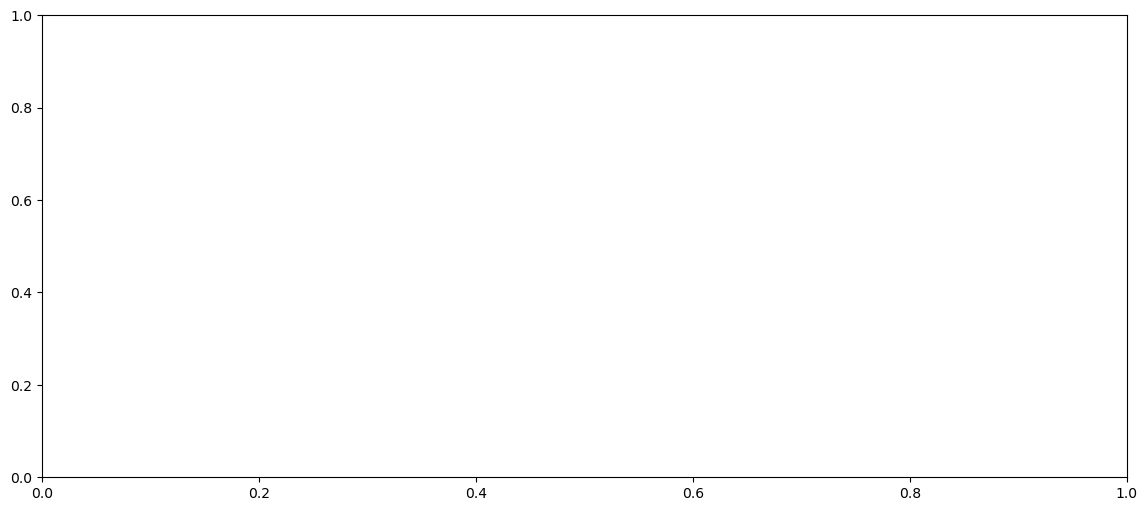

In [16]:
# ---- Global DOC map ----

cmap_doc = plt.cm.viridis
norm_doc = mcolors.Normalize(vmin=40, vmax=85)

if HAS_CARTOPY:
    fig = plt.figure(figsize=(14, 7))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="#d4c9a8", edgecolor="#999", linewidth=0.4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="#555")
    ax.gridlines(color="#aaa", linestyle="--", linewidth=0.4, alpha=0.6,
                 xlocs=range(-180, 181, 60), ylocs=range(-90, 91, 30))
    im = ax.pcolormesh(lon, lat, DOC_map, cmap=cmap_doc, norm=norm_doc,
                       transform=ccrs.PlateCarree(), shading="auto", rasterized=True)
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.pcolormesh(lon, lat, DOC_map, cmap=cmap_doc, norm=norm_doc,
                       shading="auto", rasterized=True)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_xticks(range(-180, 181, 60))
    ax.set_yticks(range(-90, 91, 30))
    ax.grid(True, linestyle="--", alpha=0.4)

cb = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.035,
                  pad=0.04, aspect=40)
cb.set_label("Surface DOC [µmol L⁻¹]", fontsize=11)
cb.ax.tick_params(labelsize=9)

stub_note = " (demo — stub model)" if stub_ANNb else ""
ax.set_title(f"Global surface DOC estimated by DOC-ANNb{stub_note}"
             f"(Bonelli et al., 2022 — Remote Sensing of Environment)",
             fontsize=12, pad=10)

plt.tight_layout()
out_png = f"{OUTPUT_DIR}global_DOC_map.png"
plt.savefig(out_png, dpi=180, bbox_inches="tight")
plt.show()
print(f"Map saved to {out_png}")

## Section 6 — Save output as NetCDF

The DOC map is saved in the same format used by Bonelli et al. (2022),
with lat/lon dimensions and DOC [µmol/L] as the main variable.

In [ ]:
from netCDF4 import Dataset
import time

out_nc = f"{OUTPUT_DIR}DOC_ANNs_global_demo.nc"

ds = Dataset(out_nc, "w", format="NETCDF4_CLASSIC")
ds.title = "Surface DOC estimated by DOC-ANNs (Bonelli et al., 2022)"
ds.institution = "DOI: 10.1016/j.rse.2022.113227"
ds.history = f"Created: {time.strftime('%Y-%m-%d %H:%M:%S')}"
ds.comment = "Demo output — replace synthetic fields with real GlobColour satellite data"

ds.createDimension("lat", nlat)
ds.createDimension("lon", nlon)

v_lat = ds.createVariable("lat", np.float32, ("lat",))
v_lon = ds.createVariable("lon", np.float32, ("lon",))
v_doc = ds.createVariable("DOC", np.float32, ("lat", "lon"),
                           fill_value=np.float32(1e20))

v_lat.units = "degrees_north"
v_lon.units = "degrees_east"
v_doc.units = "umol/L"
v_doc.long_name = "Surface dissolved organic carbon concentration"
v_doc.model = "DOC-ANNb (open ocean, OWC classes 10-17)"

v_lat[:] = lat
v_lon[:] = lon
v_doc[:, :] = np.where(np.isnan(DOC_map), 1e20, DOC_map.astype(np.float32))

ds.close()
print(f"NetCDF saved to {out_nc}")
print(f"  Dimensions: {nlat} lat x {nlon} lon")
print(f"  Variable: DOC [umol/L]")

## Section 7 — Zonal mean DOC profile

The zonal mean shows the typical latitudinal gradient of surface DOC:
higher concentrations at high latitudes (deep winter mixing, river inputs)
and lower values in the oligotrophic subtropical gyres.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 7))

zonal_mean = np.nanmean(DOC_map, axis=1)
zonal_std  = np.nanstd(DOC_map, axis=1)

ax.fill_betweenx(lat, zonal_mean - zonal_std, zonal_mean + zonal_std,
                 alpha=0.25, color="#1565c0", label="±1 std")
ax.plot(zonal_mean, lat, color="#1565c0", linewidth=2, label="Zonal mean")

ax.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax.set_xlabel("DOC [µmol L⁻¹]", fontsize=11)
ax.set_ylabel("Latitude [°]", fontsize=11)
ax.set_ylim(-90, 90)
ax.set_yticks(range(-90, 91, 30))
ax.set_xlim(35, 100)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.35)
stub_note = " (demo)" if stub_ANNb else ""
ax.set_title(f"Zonal mean surface DOC{stub_note}", fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}zonal_mean_DOC.png", dpi=150, bbox_inches="tight")
plt.show()

## Next steps

- **Replace synthetic data** with real GlobColour satellite NetCDF files
  by updating the `GLOB_*` paths in the configuration cell.
- **Add the OWC switch** to apply DOC-ANNa to coastal pixels — see `examples/predict_from_netcdf.py`
  for the full pipeline including optical water class classification.
- **Process time series**: loop over multiple 8-day composites to generate
  seasonal or annual DOC maps (see the original `run_DOCNNs.py` script).
- **Request model weights** at abonelli@asu.edu if the `.h5` files are not yet in `models/`.
